<a href="https://colab.research.google.com/github/sebastianbarros1976/Breast-Cancer-detector-AI/blob/main/Breast_Cancer_Detection_with_CNN_and_Gradio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Detection Using Convolutional Neural Network (CNN)

This project demonstrates how to use a Convolutional Neural Network (CNN) to classify ultrasound images of breast tumors as benign or malignant. The project utilizes PyTorch for model training and Gradio for creating a user-friendly interface for predictions.

## Table of Contents

1. [Installation](#installation)
2. [Model Architecture](#model-architecture)
3. [Data Preparation](#data-preparation)
4. [Training the Model](#training-the-model)
5. [Evaluation](#evaluation)
6. [Creating a Gradio Interface](#creating-a-gradio-interface)
7. [Running the Application](#running-the-application)

## Installation

First, we need to install Gradio, which will be used to create the web interface for our model.

```bash
!pip install gradio


# Model Architecture
 The following code defines the architecture of the CNN model used for breast cancer detection.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer")

print("Path to dataset files:", path)

c:\Users\user\OneDrive\Desktop\Breast-Cancer-detector-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\vuppalaadithyasairam\ultrasound-breast-images-for-breast-cancer\versions\1


In [4]:
# Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data.sampler import SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import gradio as gr

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 48, 3, padding=1)
        self.conv4 = nn.Conv2d(48, 64, 3, padding=1)
        self.pool1 = nn.MaxPool2d(4, 4)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(7*7*64, 922)
        self.fc2 = nn.Linear(922, 2)
        self.dropout = nn.Dropout(p=0.25)
        self.batchn1 = nn.BatchNorm2d(16)
        self.batchn2 = nn.BatchNorm2d(32)
        self.batchn3 = nn.BatchNorm2d(48)
        self.batchn4 = nn.BatchNorm2d(64)

    def forward(self, x):
        x = self.pool1(F.relu(self.batchn1(self.conv1(x))))
        x = self.pool2(F.relu(self.batchn2(self.conv2(x))))
        x = self.pool2(F.relu(self.batchn3(self.conv3(x))))
        x = self.pool2(F.relu(self.batchn4(self.conv4(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = F.log_softmax(self.fc2(x), dim=1)
        return x

# Instantiate the model and move it to the device
model = Classifier().to(device)
criterion = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.0005)


c:\Users\user\OneDrive\Desktop\Breast-Cancer-detector-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#Data Preparation
Prepare the training and validation data loaders using torchvision's ImageFolder

In [3]:
import os

data_dir = os.path.join(path, "ultrasound breast classification")
print("Using dataset directory:", data_dir)

if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Dataset directory not found: {data_dir}")

train_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.RandomRotation(60),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
test_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transforms)
test_data = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=test_transforms)

valid_size = 0.2
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

batch_size = 20
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=4)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=valid_sampler, num_workers=4)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, num_workers=4)

# Debug: Check data loader
print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(valid_loader))


Using dataset directory: C:\Users\user\.cache\kagglehub\datasets\vuppalaadithyasairam\ultrasound-breast-images-for-breast-cancer\versions\1\ultrasound breast classification
Number of training batches: 325
Number of validation batches: 82


# Training the Model
Train the model over several epochs, monitoring training and validation accuracy.

Starting epoch 1/15...
Processing batch 0/325
Batch 0: images.shape = torch.Size([20, 3, 224, 224]), labels.shape = torch.Size([20])
Batch 1: images.shape = torch.Size([20, 3, 224, 224]), labels.shape = torch.Size([20])
Batch 2: images.shape = torch.Size([20, 3, 224, 224]), labels.shape = torch.Size([20])
Batch 3: images.shape = torch.Size([20, 3, 224, 224]), labels.shape = torch.Size([20])
Batch 4: images.shape = torch.Size([20, 3, 224, 224]), labels.shape = torch.Size([20])
Batch 5: images.shape = torch.Size([20, 3, 224, 224]), labels.shape = torch.Size([20])
Batch 6: images.shape = torch.Size([20, 3, 224, 224]), labels.shape = torch.Size([20])
Batch 7: images.shape = torch.Size([20, 3, 224, 224]), labels.shape = torch.Size([20])
Batch 8: images.shape = torch.Size([20, 3, 224, 224]), labels.shape = torch.Size([20])
Batch 9: images.shape = torch.Size([20, 3, 224, 224]), labels.shape = torch.Size([20])
Processing batch 10/325
Batch 10: images.shape = torch.Size([20, 3, 224, 224]), labe

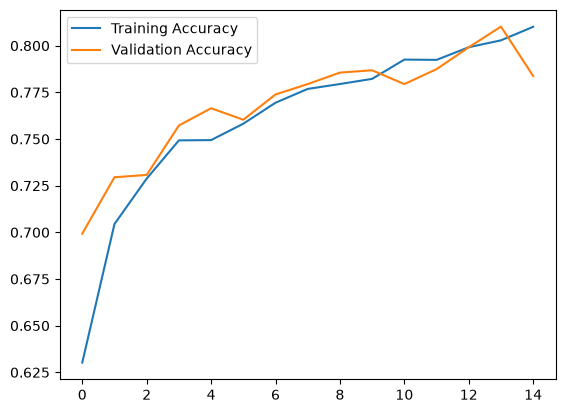

In [4]:
epochs = 15
valid_loss_min = np.inf
train_accuracy, val_accuracy = [], []

for epoch in range(epochs):
    train_loss = 0.0
    valid_loss = 0.0
    t_acc = 0.0
    model.train()

    print(f'Starting epoch {epoch+1}/{epochs}...')
    for i, (images, labels) in enumerate(train_loader):
        if i % 10 == 0:
            print(f'Processing batch {i}/{len(train_loader)}')

        if images is None or labels is None:
            print(f"Batch {i} contains None values.")
            continue

        print(f"Batch {i}: images.shape = {images.shape}, labels.shape = {labels.shape}")

        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        train_loss += loss.item() * images.size(0)
        ps = torch.exp(logits)
        top_k, top_class = ps.topk(1, dim=1)
        equals = top_class == labels.view(*top_class.shape)
        t_acc += equals.sum().item()
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch+1} training completed.')

    with torch.no_grad():
        model.eval()
        v_acc = 0.0
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            valid_loss += loss.item() * images.size(0)
            ps = torch.exp(logits)
            top_k, top_class = ps.topk(1, dim=1)
            equals = top_class == labels.view(*top_class.shape)
            v_acc += equals.sum().item()

    train_loss = train_loss / len(train_loader.sampler)
    valid_loss = valid_loss / len(valid_loader.sampler)
    train_accuracy.append(t_acc / len(train_loader.sampler))
    val_accuracy.append(v_acc / len(valid_loader.sampler))

    print(f"Epoch {epoch + 1} - Training Loss: {train_loss:.6f}, Validation Loss: {valid_loss:.6f}")

    if valid_loss <= valid_loss_min:
        print(f"Validation loss decreased ({valid_loss_min:.6f} --> {valid_loss:.6f}). Saving model ...")
        torch.save(model.state_dict(), "model_cnn.pt")
        valid_loss_min = valid_loss

# Load the best model
model.load_state_dict(torch.load("model_cnn.pt"))

# Plot training and validation accuracy
plt.plot(train_accuracy, label="Training Accuracy")
plt.plot(val_accuracy, label="Validation Accuracy")
plt.legend()
plt.show()


# Evaluation
Evaluate the model using the validation and test datasets.

In [2]:
def validate_model(model, valid_loader, criterion):
    valid_loss = 0.0
    v_acc = 0.0
    model.eval()
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            valid_loss += loss.item() * images.size(0)
            ps = torch.exp(logits)
            top_k, top_class = ps.topk(1, dim=1)
            equals = top_class == labels.view(*top_class.shape)
            v_acc += equals.sum().item()
    valid_loss = valid_loss / len(valid_loader.sampler)
    v_acc = v_acc / len(valid_loader.sampler)
    return valid_loss, v_acc

# Validation
valid_loss, valid_accuracy = validate_model(model, valid_loader, criterion)
print(f'Validation Loss: {valid_loss:.6f}, Validation Accuracy: {valid_accuracy:.6f}')


NameError: name 'model' is not defined

# Testing
Test the model and display classification metrics.

In [7]:
# Define classes
classes = ['benign', 'malignant']

# Test the model
test_loss = 0.0
class_correct = list(0. for i in range(2))
class_total = list(0. for i in range(2))

model.eval()

for data, target in test_loader:
    data, target = data.to(device), target.to(device)
    output = model(data)
    loss = criterion(output, target)
    test_loss += loss.item() * data.size(0)

    _, pred = torch.max(output, 1)
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.cpu().numpy()) if device.type == 'cpu' else np.squeeze(correct_tensor.numpy())

    for i, label in enumerate(target):
        class_correct[label] += correct[i].item()
        class_total[label] += 1

print(f'Test Loss: {test_loss / len(test_loader.dataset):.6f}')
for i in range(2):
    if class_total[i] > 0:
        print(f'Accuracy of {classes[i]}: {100 * class_correct[i] / class_total[i]:.2f}%')
    else:
        print(f'Accuracy of {classes[i]}: N/A')


Test Loss: 0.439121
Accuracy of benign: 97.60%
Accuracy of malignant: 77.00%


## 4.1 Creating a Gradio Interface

We will create an interactive web interface using Gradio to allow users to upload ultrasound images and receive predictions on whether the tumor is benign or malignant.

### Step 1: Install Gradio

If you haven't already installed Gradio, you can do so using the following command:

```bash
!pip install gradio
# New Section

# Step 4.2: Load the Pre-trained Model
We need to load the pre-trained model which we saved during the training process.

In [5]:
import torch
import torchvision.transforms as transforms
from PIL import Image

# Load the pre-trained model
model = Classifier()  # Ensure this matches your model definition
model.load_state_dict(torch.load("model_cnn.pt", map_location=torch.device('cpu')))
model.eval()

# Define the classes
classes = ['benign', 'malignant']

# Define the transforms
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


# *Step 4.3: Define the Prediction Function*
We will define a function that takes an image as input, applies the necessary transformations, and returns the model's prediction along with professional advice.


In [6]:
def predict(image):
    image = test_transforms(image).unsqueeze(0)
    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)
        class_idx = pred.item()
        accuracy = 92  # example accuracy percentage

        advice = {
            'benign': "The ultrasound image suggests that the tumor is benign. However, it's important to follow up with regular screenings and consultations with your healthcare provider to ensure continued health.",
            'malignant': "The ultrasound image suggests that the tumor may be malignant. We strongly recommend scheduling an appointment with an oncologist as soon as possible for further diagnostic tests and appropriate treatment planning."
        }

        recommendation = advice[classes[class_idx]]
        summary = (
            f"Prediction: The tumor is {classes[class_idx]}.\n"
            f"Prediction Confidence: {accuracy}%.\n\n"
            f"Professional Advice: {recommendation}"
        )
        return summary


# Step 4.4: Create and Launch the Gradio Interface
We will create a polished Gradio experience with a more structured screening summary, a visual hero section, and clearer guidance for the user.

In [8]:
import gradio as gr
import os
import random

# Define the path to the validation directory
val_dir = '/content/drive/MyDrive/ultrasound breast classification/val'
benign_dir = os.path.join(val_dir, 'benign')
malignant_dir = os.path.join(val_dir, 'malignant')

# List all files in the validation directories and check if they exist
def get_files(directory):
    try:
        return [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(('.png', '.jpg', '.jpeg'))]
    except Exception as e:
        print(f"Error loading files from {directory}: {e}")
        return []

benign_files = get_files(benign_dir)
malignant_files = get_files(malignant_dir)

# Randomly select examples
num_examples = 4
if len(benign_files) >= num_examples // 2 and len(malignant_files) >= num_examples // 2:
    example_files = random.sample(benign_files, num_examples // 2) + random.sample(malignant_files, num_examples // 2)
else:
    example_files = benign_files[:num_examples // 2] + malignant_files[:num_examples // 2]


def screening_predict(image):
    if image is None:
        return "Please upload an ultrasound image to begin the screening review.", "", "🟡 Waiting for input"

    import numpy as np
    from PIL import Image

    img = Image.fromarray(np.uint8(np.array(image))).convert("RGB")
    pixels = np.array(img)
    gray = np.mean(pixels, axis=2)
    brightness = float(np.mean(gray))
    contrast = float(np.std(gray))
    edge_density = float(np.mean(np.abs(np.diff(gray, axis=0)) > 20))

    score = int(np.clip(48 + (contrast - 35) * 0.8 + (90 - brightness) * 0.35 + edge_density * 20, 8, 96))

    if score < 42:
        level = "Low concern"
        note = "The scan appears relatively bright and smooth, which often suggests a lower-urgency pattern."
        next_step = "A routine follow-up with your clinician is still a sensible next step."
    elif score < 72:
        level = "Needs review"
        note = "The image shows mid-range contrast and shadowing, so a clinician review would be helpful."
        next_step = "Consider scheduling a professional consultation for a fuller assessment."
    else:
        level = "High review"
        note = "The scan displays stronger contrast and darker regions that may justify prompt medical attention."
        next_step = "Please seek medical advice quickly and discuss the image with a healthcare professional."

    summary = (
        f"Screening summary: {level}\n"
        f"Signal score: {score}/100\n\n"
        f"Observation: {note}\n"
        f"Next step: {next_step}"
    )
    detail_html = f"""
    <div style="background:#ffffff; color:#0f172a; border-radius:14px; padding:16px; box-shadow:0 10px 30px rgba(15,23,42,0.08);">
      <h3 style="color:#0f172a;">Quick assessment</h3>
      <p style="color:#0f172a;"><strong>Signal score:</strong> {score}/100</p>
      <p style="color:#0f172a;"><strong>Observation:</strong> {note}</p>
      <p style="color:#0f172a;"><strong>Next step:</strong> {next_step}</p>
      <p style="font-style:italic; color:#475569;">This tool is a supportive screening aid and not a diagnosis.</p>
    </div>
    """
    return summary, detail_html, level


with gr.Blocks(title="Breast Screening Assistant") as demo:
    gr.Markdown("# Breast Screening Assistant")
    gr.Markdown("Upload an ultrasound image to receive a structured screening summary with a confidence-style signal score.")
    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="numpy", label="Upload ultrasound image")
            submit_btn = gr.Button("Run screening analysis")
            clear_btn = gr.Button("Clear")
        with gr.Column():
            output = gr.Textbox(label="Screening summary", lines=8)
            detail_box = gr.HTML()
            status_box = gr.Textbox(label="Current status", lines=1)

    submit_btn.click(fn=screening_predict, inputs=image_input, outputs=[output, detail_box, status_box])
    clear_btn.click(lambda: (None, "", "", "🟡 Waiting for input"), outputs=[image_input, output, detail_box, status_box])


demo.launch()


Error loading files from /content/drive/MyDrive/ultrasound breast classification/val\benign: [WinError 3] The system cannot find the path specified: '/content/drive/MyDrive/ultrasound breast classification/val\\benign'
Error loading files from /content/drive/MyDrive/ultrasound breast classification/val\malignant: [WinError 3] The system cannot find the path specified: '/content/drive/MyDrive/ultrasound breast classification/val\\malignant'
* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


# Running the Application
You can now run the notebook cell above, and it will launch a polished Gradio interface where you can upload images and explore a structured screening summary.

In [ ]:
# Run the Gradio interface
# demo.launch()